In [1]:
import numpy as np
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_moons
from sklearn.preprocessing import PolynomialFeatures
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

# Generate moons dataset
X, y = make_moons(n_samples=10000, noise=0.4, random_state=42)

# Split the dataset into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")


Training set size: 8000
Test set size: 2000


In [2]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for hyperparameter tuning
param_grid = {
    'max_leaf_nodes': [2, 5, 10, 20, 50, 100, 200, 500, 1000],
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10, 20]
}

# Create a DecisionTreeClassifier
tree_clf = DecisionTreeClassifier(random_state=42)

# Perform grid search with cross-validation
# Note: n_jobs=1 to avoid output duplication in Jupyter
grid_search = GridSearchCV(tree_clf, param_grid, cv=5, 
                          scoring='accuracy', verbose=1, n_jobs=1)

# Fit the grid search to the training data
grid_search.fit(X_train, y_train)

# Display the best parameters and best score in a single print
results = f"""
Best parameters: {grid_search.best_params_}
Best cross-validation score: {grid_search.best_score_:.4f}
Test set score: {grid_search.best_estimator_.score(X_test, y_test):.4f}
"""
print(results)

Fitting 5 folds for each of 180 candidates, totalling 900 fits

Best parameters: {'max_depth': None, 'max_leaf_nodes': 20, 'min_samples_split': 2}
Best cross-validation score: 0.8586
Test set score: 0.8700


Best parameters: {'max_depth': None, 'max_leaf_nodes': 20, 'min_samples_split': 2}
Best cross-validation score: 0.8586
Test set score: 0.8700



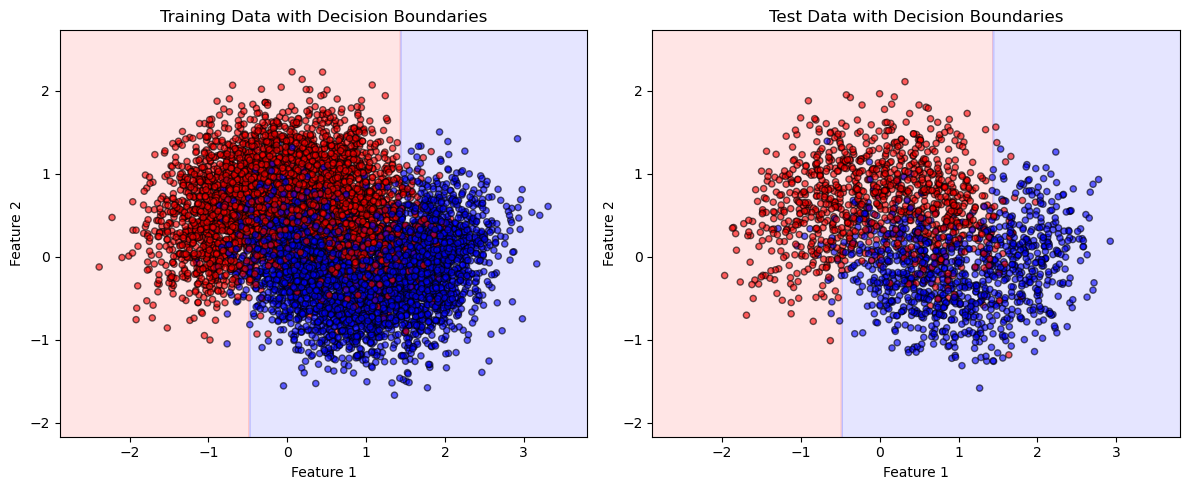

In [3]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# Get the best model from grid search
best_tree = grid_search.best_estimator_

# Create a mesh to plot decision boundaries
x_min, x_max = X_train[:, 0].min() - 0.5, X_train[:, 0].max() + 0.5
y_min, y_max = X_train[:, 1].min() - 0.5, X_train[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

# Predict on the mesh
Z = best_tree.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Create the plot
plt.figure(figsize=(12, 5))

# Plot 1: Training data with decision boundaries
plt.subplot(1, 2, 1)
plt.contourf(xx, yy, Z, alpha=0.3, cmap=ListedColormap(['#FFAAAA', '#AAAAFF']))
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=ListedColormap(['#FF0000', '#0000FF']), 
            edgecolors='k', s=20, alpha=0.6)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Training Data with Decision Boundaries')

# Plot 2: Test data with decision boundaries
plt.subplot(1, 2, 2)
plt.contourf(xx, yy, Z, alpha=0.3, cmap=ListedColormap(['#FFAAAA', '#AAAAFF']))
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap=ListedColormap(['#FF0000', '#0000FF']), 
            edgecolors='k', s=20, alpha=0.6)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Test Data with Decision Boundaries')

plt.tight_layout()
plt.show()

In [4]:
# Check the actual properties of the best tree
print("Actual tree properties:")
print(f"Max depth reached: {best_tree.get_depth()}")
print(f"Number of leaves: {best_tree.get_n_leaves()}")
print(f"Total number of nodes: {best_tree.tree_.node_count}")

Actual tree properties:
Max depth reached: 7
Number of leaves: 20
Total number of nodes: 39
